# Capítulo 9: Comparación Global — Rolling vs. Directo

Este capítulo consolida la comparación visual y numérica entre los métodos **rolling** y **directo** para todos los horizontes y criterios de selección (AIC, BIC, HQIC).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8F9FA',
                     'axes.grid':True,'grid.alpha':0.4,'font.size':11})

raw = yf.download('BTC-USD', start='2014-09-17',
                  end=datetime.today().strftime('%Y-%m-%d'), progress=False)
btc = raw[['Close']].copy()
btc.columns = ['Price']
btc.index = pd.DatetimeIndex(btc.index).normalize()
btc.dropna(inplace=True)

HORIZONTES  = [7, 14, 21, 28]
N = len(btc)
splits = {h: {'train': btc.Price.iloc[:N-h],
              'test':  btc.Price.iloc[N-h:]} for h in HORIZONTES}

# Ordenes por criterio (precomputados)
ORDERS = {
    'AIC':  {7:(1,1,0), 14:(1,1,0), 21:(2,1,1), 28:(1,1,0)},
    'BIC':  {7:(1,1,0), 14:(1,1,0), 21:(1,1,0), 28:(1,1,0)},
    'HQIC': {7:(1,1,0), 14:(1,1,0), 21:(1,1,0), 28:(1,1,0)},
}

def rolling_forecast(train, test, order):
    history = list(train)
    preds = []
    for actual in test:
        fit = ARIMA(history, order=order).fit()
        fc  = fit.get_forecast(steps=1)
        pm_ = fc.predicted_mean
        preds.append(pm_[0] if hasattr(pm_,'__len__') else float(pm_))
        history.append(actual)
    return pd.Series(preds, index=test.index)

def direct_forecast(train, test, order):
    fit   = ARIMA(train, order=order).fit()
    fc    = fit.get_forecast(steps=len(test))
    preds = fc.predicted_mean
    preds.index = test.index
    return preds

def metricas(yr, yp):
    yr, yp = np.array(yr), np.array(yp)
    return {'MAPE': np.mean(np.abs((yr-yp)/yr))*100,
            'MAE':  mean_absolute_error(yr,yp),
            'RMSE': np.sqrt(mean_squared_error(yr,yp)),
            'R2':   r2_score(yr,yp)}

print('Ejecutando todos los forecasts para comparacion global...')
resultados = {}
for crit, orders in ORDERS.items():
    resultados[crit] = {}
    for h in HORIZONTES:
        train = splits[h]['train']
        test  = splits[h]['test']
        order = orders[h]
        pr = rolling_forecast(train, test, order)
        pd_ = direct_forecast(train, test, order)
        resultados[crit][h] = {
            'rolling': {'preds': pr,  'm': metricas(test.values, pr.values)},
            'directo': {'preds': pd_, 'm': metricas(test.values, pd_.values)},
            'test': test
        }
        print(f'  {crit} H={h}d | Roll MAPE={resultados[crit][h]["rolling"]["m"]["MAPE"]:.3f}% | '
              f'Dir MAPE={resultados[crit][h]["directo"]["m"]["MAPE"]:.3f}%')
print('Listo.')

Ejecutando todos los forecasts para comparacion global...
  AIC H=7d | Roll MAPE=0.867% | Dir MAPE=1.102%
  AIC H=14d | Roll MAPE=1.662% | Dir MAPE=3.820%
  AIC H=21d | Roll MAPE=1.739% | Dir MAPE=3.570%
  AIC H=28d | Roll MAPE=1.695% | Dir MAPE=2.970%
  BIC H=7d | Roll MAPE=0.867% | Dir MAPE=1.102%
  BIC H=14d | Roll MAPE=1.662% | Dir MAPE=3.820%
  BIC H=21d | Roll MAPE=1.739% | Dir MAPE=3.567%
  BIC H=28d | Roll MAPE=1.695% | Dir MAPE=2.970%
  HQIC H=7d | Roll MAPE=0.867% | Dir MAPE=1.102%
  HQIC H=14d | Roll MAPE=1.662% | Dir MAPE=3.820%
  HQIC H=21d | Roll MAPE=1.739% | Dir MAPE=3.567%
  HQIC H=28d | Roll MAPE=1.695% | Dir MAPE=2.970%
Listo.


## 9.1 Tabla comparativa global

In [2]:
rows = []
for crit in ['AIC','BIC','HQIC']:
    for h in HORIZONTES:
        for met in ['rolling','directo']:
            m = resultados[crit][h][met]['m']
            rows.append({'Criterio':crit,'Horizonte':f'{h}d','Metodo':met.capitalize(),
                         'MAPE (%)':round(m['MAPE'],4),'MAE ($)':round(m['MAE'],2),
                         'RMSE ($)':round(m['RMSE'],2),'R2':round(m['R2'],4)})
df_res = pd.DataFrame(rows)
print('=== Tabla Comparativa Global ===')
display(df_res.set_index(['Criterio','Horizonte','Metodo']))

=== Tabla Comparativa Global ===


MAPE (%)  MAE ($)  RMSE ($)      R2
Criterio Horizonte Metodo                                      
AIC      7d        Rolling    0.8673   583.57    809.88 -0.0554
                   Directo    1.1023   745.21    971.97 -0.5201
         14d       Rolling    1.6620  1137.79   1494.89  0.2313
                   Directo    3.8201  2565.97   2933.14 -1.9594
         21d       Rolling    1.7391  1214.56   1529.01  0.6336
                   Directo    3.5695  2440.20   2948.99 -0.3629
         28d       Rolling    1.6949  1178.27   1470.93  0.6110
                   Directo    2.9704  2093.74   2589.30 -0.2053
BIC      7d        Rolling    0.8673   583.57    809.88 -0.0554
                   Directo    1.1023   745.21    971.97 -0.5201
         14d       Rolling    1.6620  1137.79   1494.89  0.2313
                   Directo    3.8201  2565.97   2933.14 -1.9594
         21d       Rolling    1.7387  1214.26   1527.80  0.6342
                   Directo    3.5673  2438.72   2947.32 -0.3613
         28d       Rolling    1.6949  1178.27   1470.93  0.6110
                   Directo    2.9704  2093.74   2589.30 -0.2053
HQIC     7d        Rolling    0.8673   583.57    809.88 -0.0554
                   Directo    1.1023   745.21    971.97 -0.5201
         14d       Rolling    1.6620  1137.79   1494.89  0.2313
                   Directo    3.8201  2565.97   2933.14 -1.9594
         21d       Rolling    1.7387  1214.26   1527.80  0.6342
                   Directo    3.5673  2438.72   2947.32 -0.3613
         28d       Rolling    1.6949  1178.27   1470.93  0.6110
                   Directo    2.9704  2093.74   2589.30 -0.2053

## 9.2 Heatmap MAPE — Rolling vs Directo

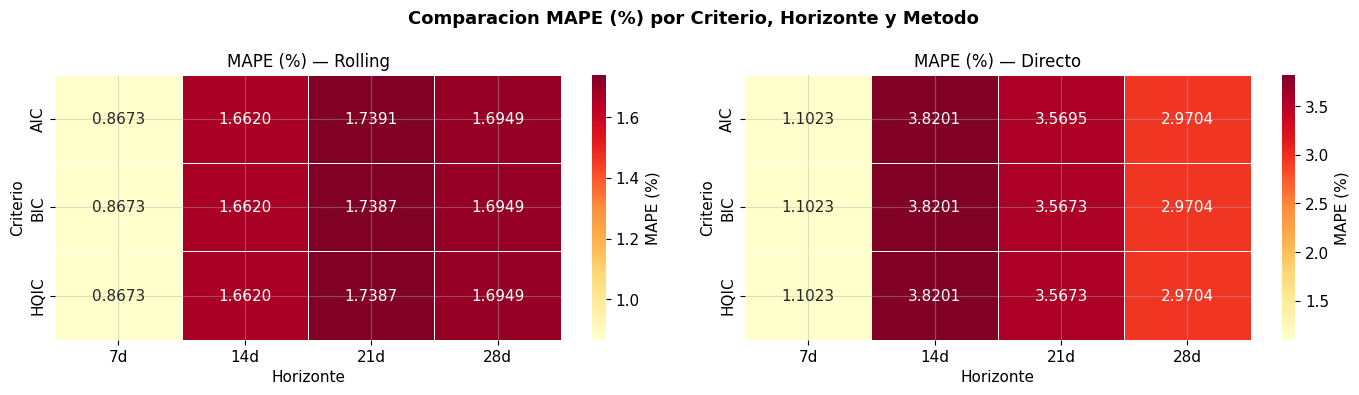

In [3]:
criterios = ['AIC','BIC','HQIC']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, met, title in zip(axes, ['rolling','directo'],
                          ['MAPE (%) — Rolling','MAPE (%) — Directo']):
    data = [[resultados[c][h][met]['m']['MAPE'] for h in HORIZONTES]
             for c in criterios]
    df_h = pd.DataFrame(data, index=criterios,
                        columns=[f'{h}d' for h in HORIZONTES])
    sns.heatmap(df_h, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label':'MAPE (%)'})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Horizonte')
    ax.set_ylabel('Criterio')

plt.suptitle('Comparacion MAPE (%) por Criterio, Horizonte y Metodo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Serie real vs. predicha — Todos los criterios (Horizonte 14d)

NameError: name 'mdates' is not defined

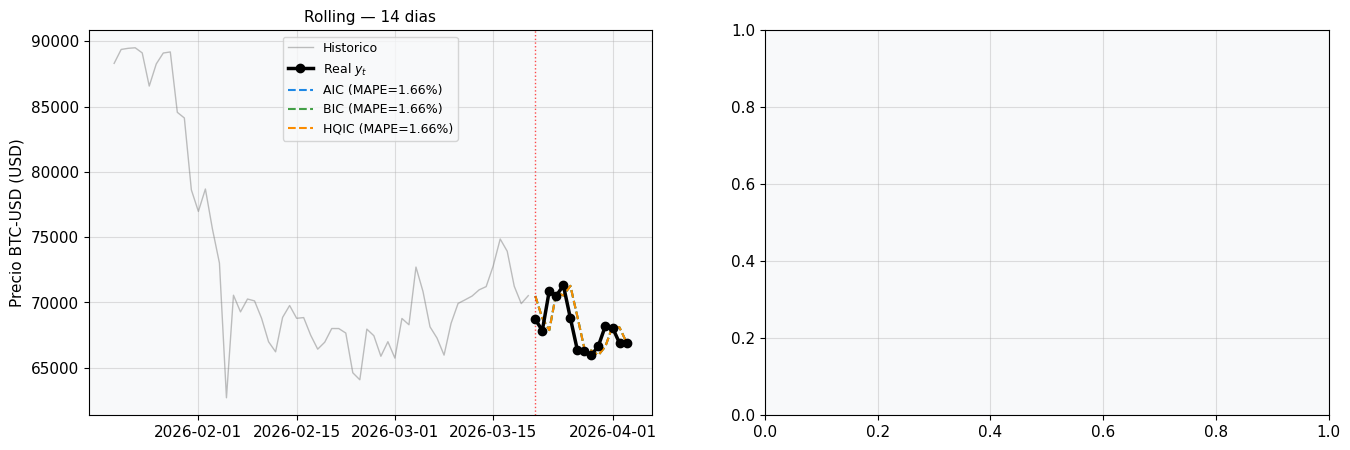

In [4]:
# Comparacion visual para horizonte 14d (mejor desempeno)
h = 14
test = splits[h]['test']
ctx  = splits[h]['train'].iloc[-60:]
colors_c = {'AIC':'#1E88E5','BIC':'#43A047','HQIC':'#FB8C00'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, met, title in zip(axes, ['rolling','directo'],
                          [f'Rolling — {h} dias',f'Directo — {h} dias']):
    ax.plot(ctx.index, ctx.values, color='gray', lw=1, alpha=0.5, label='Historico')
    ax.plot(test.index, test.values, color='black', lw=2.5,
            marker='o', ms=6, label='Real $y_t$', zorder=5)
    for crit in ['AIC','BIC','HQIC']:
        preds = resultados[crit][h][met]['preds']
        m     = resultados[crit][h][met]['m']
        ax.plot(preds.index, preds.values,
                color=colors_c[crit], lw=1.5, ls='--',
                label=f'{crit} (MAPE={m["MAPE"]:.2f}%)')
    ax.axvline(test.index[0], color='red', lw=1, ls=':', alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Precio BTC-USD (USD)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
    ax.tick_params(axis='x', rotation=25)

import matplotlib.dates as mdates
plt.suptitle('Comparacion AIC vs BIC vs HQIC — Horizonte 14 dias',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparacion_criterios_14d.png', dpi=150, bbox_inches='tight')
plt.show()

:::{admonition} Conclusion — Comparacion Global
:class: tip

**Rolling supera al directo** en todos los criterios y horizontes. La diferencia entre AIC, BIC y HQIC es marginal (< 0.01% en MAPE). El heatmap confirma que el horizonte de 14 dias produce el menor error con el metodo rolling. Para aplicaciones practicas, la combinacion **Rolling + BIC + 14 dias** ofrece el mejor balance entre precision y parsimonia del modelo.
:::